Why latent dynamics?

Raw observations can be noisy, high-dimensional, or inconvenient.

Instead, we can:
- encode each observation into a latent vector
- model temporal evolution in latent space
- decode predictions back to observation space

In [1]:
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
random.seed(42)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


Toy temporal data: moving 2D points

We create sequences of 2D observations.
Each sequence will follow a smooth motion pattern.

Observation at each time step:
[x_t, y_t]

This is simple enough to visualize directly.

In [2]:
def generate_motion_sequences(num_samples=1000, seq_len=20):
    sequences = []

    for _ in range(num_samples):
        start_x = random.uniform(-2.0, 2.0)
        start_y = random.uniform(-2.0, 2.0)

        vx = random.uniform(-0.15, 0.15)
        vy = random.uniform(-0.15, 0.15)

        seq = []

        for t in range(seq_len):
            x = start_x + vx * t + 0.2 * math.sin(0.3 * t)
            y = start_y + vy * t + 0.2 * math.cos(0.3 * t)
            seq.append([x, y])

        sequences.append(seq)

    return torch.tensor(sequences, dtype=torch.float32)

In [3]:
data = generate_motion_sequences(num_samples=4, seq_len=20)

print("shape:", data.shape)
print(data[0, :5])

shape: torch.Size([4, 20, 2])
tensor([[ 0.5577, -1.7000],
        [ 0.5493, -1.7919],
        [ 0.5357, -1.9010],
        [ 0.5119, -2.0247],
        [ 0.4742, -2.1596]])


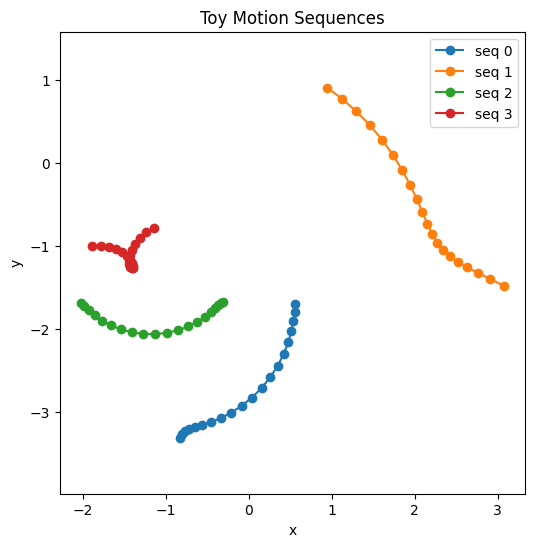

In [4]:
plt.figure(figsize=(6, 6))

for i in range(4):
    seq = data[i]
    plt.plot(seq[:, 0].numpy(), seq[:, 1].numpy(), marker="o", label=f"seq {i}")

plt.legend()
plt.title("Toy Motion Sequences")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

Build train / validation data

Input sequence:
observations from time 0 to T-2

Target sequence:
observations from time 1 to T-1

So the model learns next-step prediction.
```

In [5]:
all_data = generate_motion_sequences(num_samples=2000, seq_len=25)

X_all = all_data[:, :-1, :]
Y_all = all_data[:, 1:, :]

X_train = X_all[:1600]
Y_train = Y_all[:1600]

X_val = X_all[1600:]
Y_val = Y_all[1600:]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: torch.Size([1600, 24, 2])
Y_train shape: torch.Size([1600, 24, 2])


In [6]:
# Batch helper
def get_seq_batch(X, Y, batch_size=32):
    indices = torch.randint(0, X.shape[0], (batch_size,))
    xb = X[indices]
    yb = Y[indices]
    return xb, yb

In [7]:
xb, yb = get_seq_batch(X_train, Y_train, batch_size=4)
print(xb.shape, yb.shape)

torch.Size([4, 24, 2]) torch.Size([4, 24, 2])


Observation encoder

This turns a 2D observation into a latent vector.

Input:
(B, T, 2)

We will apply the encoder to each time step independently.

In [8]:
class ObservationEncoder(nn.Module):
    def __init__(self, obs_dim=2, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )

    def forward(self, x):
        # x shape: (B, T, obs_dim)

        B, T, D = x.shape

        x = x.view(B * T, D)      # combine batch and time so encoder can process all time steps
        z = self.net(x)           # encode each observation independently
        z = z.view(B, T, -1)      # restore time dimension

        return z

In [9]:
encoder = ObservationEncoder(obs_dim=2, latent_dim=8)

xb, yb = get_seq_batch(X_train, Y_train, batch_size=4)
z = encoder(xb)

print("input shape:", xb.shape)
print("latent shape:", z.shape)

input shape: torch.Size([4, 24, 2])
latent shape: torch.Size([4, 24, 8])


Latent dynamics model

Now we use a GRU to model how latent representations evolve over time.

Input:
latent sequence z_t

Output:
hidden state sequence h_t

In [10]:
class LatentDynamics(nn.Module):
    def __init__(self, latent_dim=8, hidden_dim=16):
        super().__init__()
        self.gru = nn.GRU(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

    def forward(self, z):
        # z shape: (B, T, latent_dim)
        h_seq, h_n = self.gru(z)
        return h_seq, h_n

In [11]:
dynamics = LatentDynamics(latent_dim=8, hidden_dim=16)

h_seq, h_n = dynamics(z)

print("z shape:", z.shape)
print("h_seq shape:", h_seq.shape)
print("h_n shape:", h_n.shape)

z shape: torch.Size([4, 24, 8])
h_seq shape: torch.Size([4, 24, 16])
h_n shape: torch.Size([1, 4, 16])


Prediction head

We want to predict the next observation from the hidden state.

Input:
hidden state h_t

Output:
predicted next observation

In [16]:
class ObservationDecoder(nn.Module):
    def __init__(self, hidden_dim=16, obs_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, obs_dim)
        )

    def forward(self, h):
        # h shape: (B, T, hidden_dim)

        B, T, D = h.shape

        h = h.reshape(B * T, D)
        out = self.net(h)
        out = out.reshape(B, T, -1)

        return out

In [17]:
decoder = ObservationDecoder(hidden_dim=16, obs_dim=2)
pred = decoder(h_seq)

print("pred shape:", pred.shape)

pred shape: torch.Size([4, 24, 2])


Full latent dynamics predictor

This model does:

observation -> encoder -> latent -> GRU dynamics -> decoder -> predicted next observation

In [18]:
class LatentDynamicsModel(nn.Module):
    def __init__(self, obs_dim=2, latent_dim=8, hidden_dim=16):
        super().__init__()

        self.encoder = ObservationEncoder(obs_dim=obs_dim, latent_dim=latent_dim)
        self.dynamics = LatentDynamics(latent_dim=latent_dim, hidden_dim=hidden_dim)
        self.decoder = ObservationDecoder(hidden_dim=hidden_dim, obs_dim=obs_dim)

    def forward(self, x):
        # x shape: (B, T, obs_dim)

        z = self.encoder(x)               # encode observations into latent vectors
        h_seq, h_n = self.dynamics(z)     # recurrent dynamics over latent sequence
        pred = self.decoder(h_seq)        # predict next observation from hidden states

        return pred, z, h_seq, h_n

In [20]:
model = LatentDynamicsModel(obs_dim=2, latent_dim=8, hidden_dim=16).to(device)
print(model)

LatentDynamicsModel(
  (encoder): ObservationEncoder(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=8, bias=True)
    )
  )
  (dynamics): LatentDynamics(
    (gru): GRU(8, 16, batch_first=True)
  )
  (decoder): ObservationDecoder(
    (net): Sequential(
      (0): Linear(in_features=16, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=2, bias=True)
    )
  )
)


In [21]:
xb, yb = get_seq_batch(X_train, Y_train, batch_size=4)
xb = xb.to(device)

pred, z, h_seq, h_n = model(xb)

print("input shape:", xb.shape)
print("pred shape:", pred.shape)
print("latent shape:", z.shape)
print("hidden sequence shape:", h_seq.shape)
print("final hidden shape:", h_n.shape)

input shape: torch.Size([4, 24, 2])
pred shape: torch.Size([4, 24, 2])
latent shape: torch.Size([4, 24, 8])
hidden sequence shape: torch.Size([4, 24, 16])
final hidden shape: torch.Size([1, 4, 16])


In [22]:
criterion = nn.MSELoss()

yb = yb.to(device)
loss = criterion(pred, yb)

print("loss:", loss.item())

loss: 3.221794843673706


In [23]:
def evaluate_dynamics_model(model, X, Y, batch_size=128, num_batches=20):
    model.eval()
    criterion = nn.MSELoss()
    losses = []

    with torch.no_grad():
        for _ in range(num_batches):
            xb, yb = get_seq_batch(X, Y, batch_size=batch_size)
            xb = xb.to(device)
            yb = yb.to(device)

            pred, z, h_seq, h_n = model(xb)
            loss = criterion(pred, yb)
            losses.append(loss.item())

    model.train()
    return sum(losses) / len(losses)

In [24]:
model = LatentDynamicsModel(obs_dim=2, latent_dim=8, hidden_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

train_loss_history = []
val_loss_history = []

num_steps = 600

for step in range(num_steps):
    xb, yb = get_seq_batch(X_train, Y_train, batch_size=64)
    xb = xb.to(device)
    yb = yb.to(device)

    pred, z, h_seq, h_n = model(xb)
    loss = criterion(pred, yb)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 20 == 0:
        train_loss = evaluate_dynamics_model(model, X_train, Y_train)
        val_loss = evaluate_dynamics_model(model, X_val, Y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        print(f"Step {step:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Step 000 | Train Loss: 2.883030 | Val Loss: 2.643852
Step 020 | Train Loss: 2.453309 | Val Loss: 2.331542
Step 040 | Train Loss: 1.561276 | Val Loss: 1.541823
Step 060 | Train Loss: 0.693651 | Val Loss: 0.679298
Step 080 | Train Loss: 0.252739 | Val Loss: 0.261451
Step 100 | Train Loss: 0.125465 | Val Loss: 0.130050
Step 120 | Train Loss: 0.068970 | Val Loss: 0.080433
Step 140 | Train Loss: 0.045937 | Val Loss: 0.051212
Step 160 | Train Loss: 0.033658 | Val Loss: 0.037351
Step 180 | Train Loss: 0.027413 | Val Loss: 0.028880
Step 200 | Train Loss: 0.022973 | Val Loss: 0.022980
Step 220 | Train Loss: 0.020012 | Val Loss: 0.022135
Step 240 | Train Loss: 0.016056 | Val Loss: 0.016986
Step 260 | Train Loss: 0.014890 | Val Loss: 0.015504
Step 280 | Train Loss: 0.013081 | Val Loss: 0.013648
Step 300 | Train Loss: 0.011257 | Val Loss: 0.012157
Step 320 | Train Loss: 0.011318 | Val Loss: 0.012159
Step 340 | Train Loss: 0.009781 | Val Loss: 0.010544
Step 360 | Train Loss: 0.009380 | Val Loss: 0.

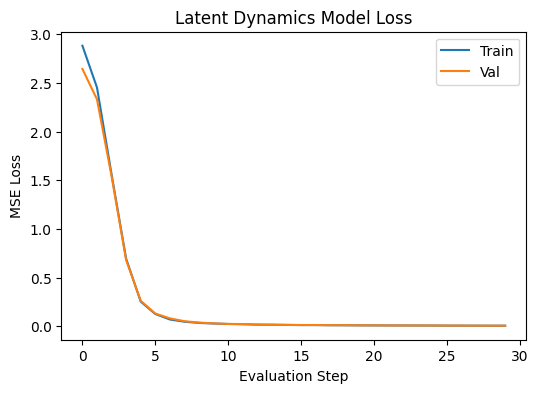

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history, label="Train")
plt.plot(val_loss_history, label="Val")
plt.legend()
plt.title("Latent Dynamics Model Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("MSE Loss")
plt.show()

In [27]:
model.eval()

xb, yb = get_seq_batch(X_val, Y_val, batch_size=4)
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    pred, z, h_seq, h_n = model(xb)

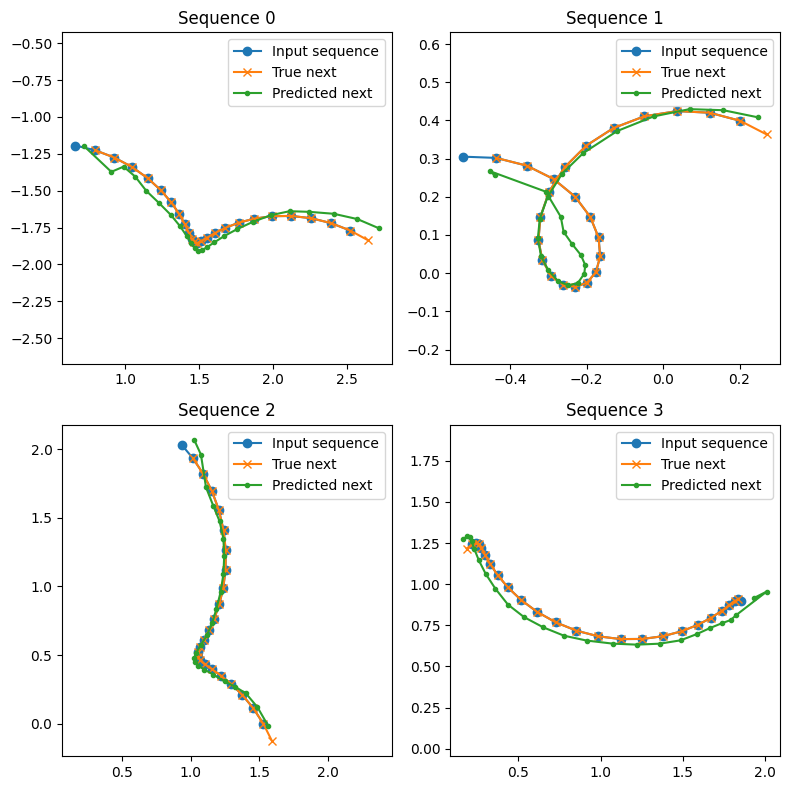

In [28]:
xb_cpu = xb.cpu()
yb_cpu = yb.cpu()
pred_cpu = pred.cpu()

plt.figure(figsize=(8, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    plt.plot(xb_cpu[i, :, 0].numpy(), xb_cpu[i, :, 1].numpy(), marker="o", label="Input sequence")
    plt.plot(yb_cpu[i, :, 0].numpy(), yb_cpu[i, :, 1].numpy(), marker="x", label="True next")
    plt.plot(pred_cpu[i, :, 0].numpy(), pred_cpu[i, :, 1].numpy(), marker=".", label="Predicted next")

    plt.legend()
    plt.title(f"Sequence {i}")
    plt.axis("equal")

plt.tight_layout()
plt.show()

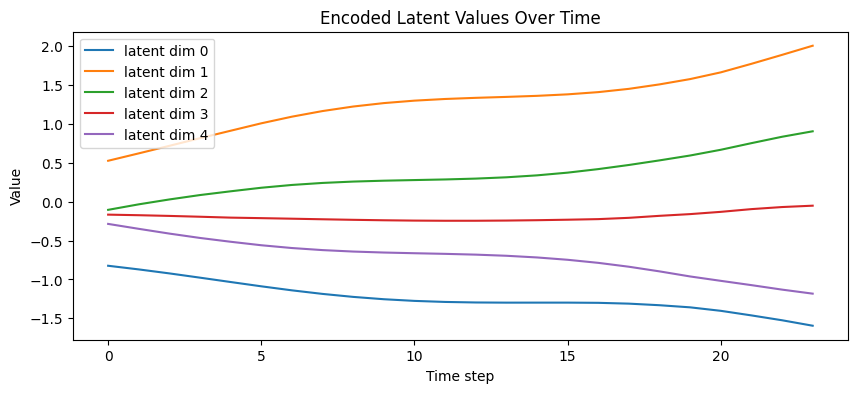

In [29]:
latent_seq = z[0].detach().cpu()   # shape: (T, latent_dim)

plt.figure(figsize=(10, 4))
for dim in range(min(5, latent_seq.shape[1])):
    plt.plot(latent_seq[:, dim].numpy(), label=f"latent dim {dim}")

plt.legend()
plt.title("Encoded Latent Values Over Time")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.show()

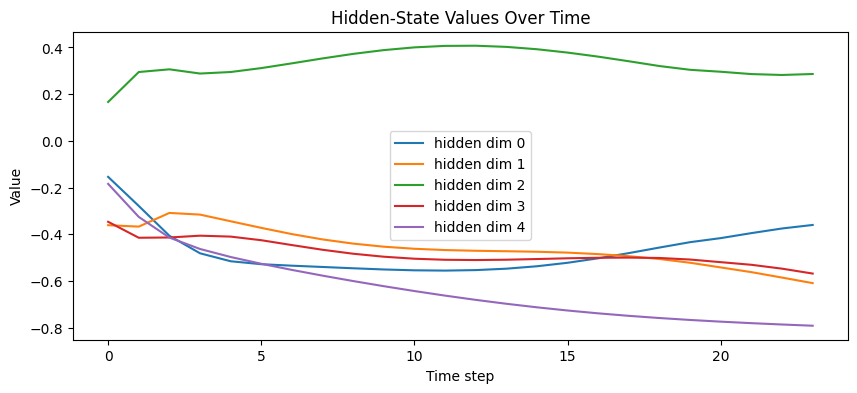

In [31]:
hidden_seq = h_seq[0].detach().cpu()   # shape: (T, hidden_dim)

plt.figure(figsize=(10, 4))
for dim in range(min(5, hidden_seq.shape[1])):
    plt.plot(hidden_seq[:, dim].numpy(), label=f"hidden dim {dim}")

plt.legend()
plt.title("Hidden-State Values Over Time")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.show()

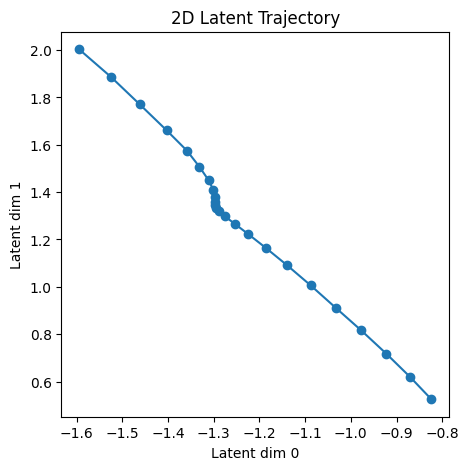

In [32]:
if latent_seq.shape[1] >= 2:
    plt.figure(figsize=(5, 5))
    plt.plot(latent_seq[:, 0].numpy(), latent_seq[:, 1].numpy(), marker="o")
    plt.title("2D Latent Trajectory")
    plt.xlabel("Latent dim 0")
    plt.ylabel("Latent dim 1")
    plt.show()

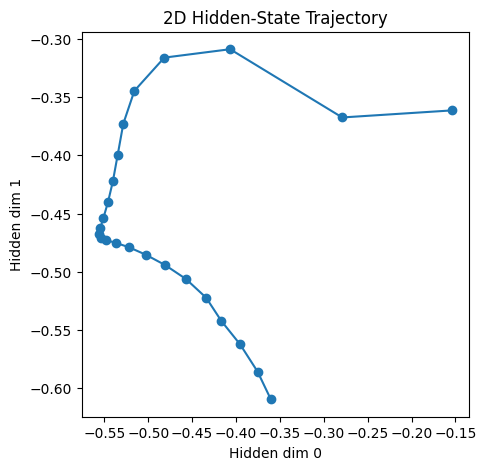

In [33]:
if hidden_seq.shape[1] >= 2:
    plt.figure(figsize=(5, 5))
    plt.plot(hidden_seq[:, 0].numpy(), hidden_seq[:, 1].numpy(), marker="o")
    plt.title("2D Hidden-State Trajectory")
    plt.xlabel("Hidden dim 0")
    plt.ylabel("Hidden dim 1")
    plt.show()

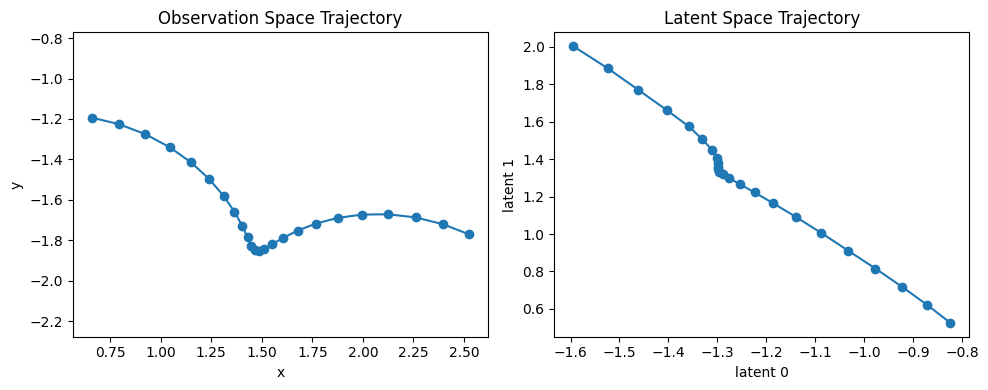

In [34]:
obs_seq = xb_cpu[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(obs_seq[:, 0].numpy(), obs_seq[:, 1].numpy(), marker="o")
plt.title("Observation Space Trajectory")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.plot(latent_seq[:, 0].numpy(), latent_seq[:, 1].numpy(), marker="o")
plt.title("Latent Space Trajectory")
plt.xlabel("latent 0")
plt.ylabel("latent 1")

plt.tight_layout()
plt.show()